# Unbiased simulations

1. Input:`data/ala2_solv.pdb`

2. Output, for $n\in[0,\mathrm{num\_steps}]$:
Working directory: `workdir/step_n/`
Create: `traj.h5`, `traj.out`, `dihedrals.npy`, `features.npy`

3. Gather output into: `workdir/dihedrals.npy`, `workdir/features.npy`

## 1. Simulation parameters

In [1]:
import openmm.unit as unit
from src.param import param_unbiased_reference
from src.util import pretty_print

p = param_unbiased_reference()
# pretty_print(p)

## 2. Perform simulations and write dihedral & feature data

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import openmm as mm
from openmm.app import Simulation, ForceField, PDBFile, HBonds

from src.data import simulation_data
from src.util import create_system, state_data_reporter, hdf5_reporter
from src.util import print_platform

step_start = 0
num_steps = 3000
do_simulation = False

if do_simulation:
    pdb = PDBFile(p.pdb_file)
    forcefield = ForceField("amber99sb.xml", "tip3p.xml")
    system = create_system(forcefield, pdb.topology)

    for step in range(step_start, num_steps):
        print(f"starting simulation {step} of {num_steps}")

        # start positions from 'sd' from previous step
        if step == 0:
            start_positions = pdb.positions
        else:
            if step == step_start:
                sd = simulation_data(p, subdir=(step - 1))
            start_positions = sd.final_positions
        assert (
            type(start_positions) == mm.unit.quantity.Quantity
        ), f"ERROR: {type(start_positions) = } in step {step}"

        # new 'sd' object for present simulation files
        sd = simulation_data(p, subdir=step)
        outfile = str(sd.files["outfile"])
        h5file = str(sd.files["h5file"])

        # each step requires new integrator, simulation object
        integrator = mm.LangevinIntegrator(p.temperature, p.friction_coeff, p.timestep)
        simulation = Simulation(pdb.topology, system, integrator)
        print_platform(simulation)
        simulation.context.setPositions(start_positions)
        sdr = state_data_reporter(outfile, p.report_interval)
        hdr = hdf5_reporter(h5file, p.report_interval)
        simulation.reporters.append(sdr)
        simulation.reporters.append(hdr)
        simulation.step(round(p.simulation_time / p.timestep))

        for reporter in simulation.reporters:
            if hasattr(reporter, "close"):
                reporter.close()

        # save 'final_positions'
        r = simulation.context.getState(getPositions=True).getPositions()
        sd.save_and_assign_objects({"final_positions": r})

        # calculate and save 'dihedrals', 'features' from 'h5file'
        sd.save_feature_data(recalculate=True)

## 3. Gather data from steps into master files

* Concatenate `dihedrals`, `features` arrays from each step
* Write combined data files to `p.working_dir`

sd.dihedrals.shape = (3000000, 2)
sd.features.shape = (3000000, 45)


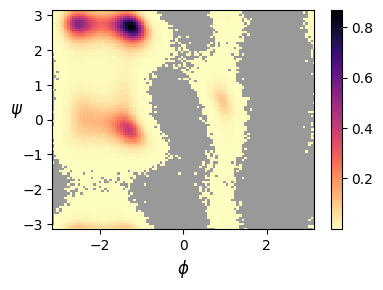

In [ ]:
from src.grid2d import hist2d
from src.dataclass import data_class, DataClass
from src.plots import plot_dihedrals_hist2d

gather_data = False
if gather_data:
    dihedrals, features = [], []
    for step in range(num_steps):
        sd = simulation_data(p, subdir=step)
        dihedrals.append(sd.dihedrals)
        features.append(sd.features)

    sd = simulation_data(p)
    sd.save_and_assign_objects(
        {"dihedrals": np.vstack(dihedrals), "features": np.vstack(features)}
    )
else:
    sd = simulation_data(p)

theta = np.linspace(-np.pi, np.pi, 100)
pdf = DataClass(x=theta, y=theta, p=hist2d(theta, theta, sd.dihedrals))
pdf = data_class(sd.working_dir, "dihedrals_pdf", pdf)

print(f"{sd.dihedrals.shape = }")
print(f"{sd.features.shape = }")

fig, ax = plt.subplots(1, 1, figsize=(4, 3))
plot_dihedrals_hist2d(fig, ax, pdf)
fig.savefig("notes/figures/unbiased-dih-hist2d.png", bbox_inches="tight")

## 4. Create tar file on `Backup Plus` and clean up

From `data/unbiased`:
```bash
$ make_tar.py /run/media/bharland/Backup\ Plus/Backup/ unbiased_june_2026.tar
$ rm -r step_*
```